# El ciclo retórico pre-bélico de EE.UU. (1991–2026)
### Evidencia empírica de un patrón de cuatro fases en cinco intervenciones militares

Las intervenciones militares de EE.UU. en el Medio Oriente no ocurren de forma espontánea: están precedidas por un ciclo retórico sistemático que construye el consenso público necesario para la guerra. Este análisis documenta ese patrón en cinco casos — Golfo (1991), Afganistán (2001), Iraq (2003), Libia (2011) e Irán (2026) — utilizando métricas de intensidad narrativa, tono mediático y cobertura de eventos derivadas de GDELT. La hipótesis central es que el ciclo se ha ido acelerando: lo que antes tomaba meses, hoy se comprime en semanas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.style.use('seaborn-v0_8-whitegrid')

# ── Fuente de datos ───────────────────────────────────────────────────────────
USE_REAL_GDELT = True  # True = descarga GDELT (requiere conexión) | False = mock parquet local

CASES = {
    'gulf_1991':        {'label': 'Golfo 1991',       'color': '#378ADD', 'tipo': 'Construcción'},
    'afghanistan_2001': {'label': 'Afganistán 2001',  'color': '#1D9E75', 'tipo': 'Redirección'},
    'iraq_2003':        {'label': 'Irak 2003',         'color': '#BA7517', 'tipo': 'Fabricación'},
    'libya_2011':       {'label': 'Libia 2011',        'color': '#7F77DD', 'tipo': 'Construcción'},
    'iran_2026':        {'label': 'Irán 2026',         'color': '#E24B4A', 'tipo': 'Fabricación'},
}
PHASE_LABELS = {
    'construccion_enemigo':  'I. Construcción del Enemigo',
    'justificacion_moral':   'II. Justificación Moral',
    'manufactura_consenso':  'III. Manufactura del Consenso',
    'escalamiento':          'IV. Escalamiento',
}

In [2]:
if USE_REAL_GDELT:
    import gdelt as gdelt_pkg

    _GDELT_V2_START = pd.Timestamp('2015-02-19')
    _INVASION_DATES = {
        'gulf_1991': '1991-01-17', 'afghanistan_2001': '2001-10-07',
        'iraq_2003': '2003-03-20', 'libya_2011':       '2011-03-19', 'iran_2026': '2026-02-28',
    }
    _CASE_COUNTRY = {
        'gulf_1991': 'IRQ', 'afghanistan_2001': 'AFG',
        'iraq_2003': 'IRQ', 'libya_2011':       'LBA', 'iran_2026': 'IRN',
    }

    def _assign_phase(d):
        if d > 45:  return 'construccion_enemigo'
        elif d > 14: return 'justificacion_moral'
        elif d > 3:  return 'manufactura_consenso'
        else:        return 'escalamiento'

    def _fetch_case(case_name, inv_str, country_code):
        invasion = pd.Timestamp(inv_str)
        start    = invasion - pd.Timedelta(days=180)
        is_v2    = start >= _GDELT_V2_START
        gd       = gdelt_pkg.gdelt(version=2 if is_v2 else 1)
        dates    = pd.date_range(start=start, end=invasion, freq='D' if is_v2 else 'W')
        raw      = gd.Search([d.strftime('%Y %m %d') for d in dates],
                             table='events', coverage=False, output='df')
        filt = raw[(raw['Actor1CountryCode'] == country_code) |
                   (raw['Actor2CountryCode'] == country_code)].copy()
        filt['date'] = pd.to_datetime(filt['SQLDATE'].astype(str), format='%Y%m%d')
        daily = filt.groupby('date').agg(
            NumArticles=('NumArticles', 'sum'), AvgTone=('AvgTone', 'mean')
        ).reset_index()
        vols        = daily['NumArticles'].values.astype(float)
        days_before = [(invasion - d).days for d in daily['date']]
        return pd.DataFrame({
            'case':                case_name,
            'date':                daily['date'].values,
            'NumArticles':         vols.astype(int),
            'AvgTone':             daily['AvgTone'].values,
            'narrative_intensity': vols / max(vols.max(), 1.0),
            'days_before_invasion':days_before,
            'phase':               [_assign_phase(d) for d in days_before],
        })

    all_dfs = []
    for case_name, inv_str in _INVASION_DATES.items():
        print(f'  → {case_name}... ', end='', flush=True)
        try:
            all_dfs.append(_fetch_case(case_name, inv_str, _CASE_COUNTRY[case_name]))
            print('✓ REAL')
        except Exception as e:
            print(f'error ({e}) — usando mock')
            mock = pd.read_parquet('../data/gdelt_mock_v3.parquet')
            all_dfs.append(mock[mock['case'] == case_name].copy())

    df = pd.concat(all_dfs, ignore_index=True)
    _source_label = '🌐 GDELT real (descargado en vivo)'
else:
    df = pd.read_parquet('../data/gdelt_mock_v3.parquet')
    _source_label = '📦 Mock parquet v3 (datos simulados — reproducible sin conexión)'

df['days_before_invasion'] = df['days_before_invasion'].abs()
df['date'] = pd.to_datetime(df['date'])

print(f'Fuente: {_source_label}')
print(f'Datos:  {len(df):,} eventos · {df["case"].nunique()} casos · {df["date"].dt.year.min()}–{df["date"].dt.year.max()}')

here
  → gulf_1991... here
here
✓ REAL
  → afghanistan_2001... here
✓ REAL
  → iraq_2003... here
here
✓ REAL
  → libya_2011... herehere

herehere

here
here
here
error (zero-size array to reduction operation maximum which has no identity) — usando mock
  → iran_2026... here
here
here
here
here
here
here
here
here
here
here
here
✓ REAL
Fuente: 🌐 GDELT real (descargado en vivo)
Datos:  2,270 eventos · 5 casos · 1990–2026


## 1. Las cuatro fases del ciclo retórico

El ciclo retórico pre-bélico se estructura en cuatro fases progresivas: primero se construye la imagen del enemigo como amenaza existencial; luego se articula una justificación moral que legitima la acción; después se manufactura un consenso doméstico e internacional; y finalmente se produce el escalamiento hacia la acción militar directa. Cada fase eleva la intensidad narrativa medible en la cobertura mediática. Las líneas verticales en los gráficos demarcan los umbrales aproximados entre fases: D-45, D-14 y D-3 antes de la invasión.

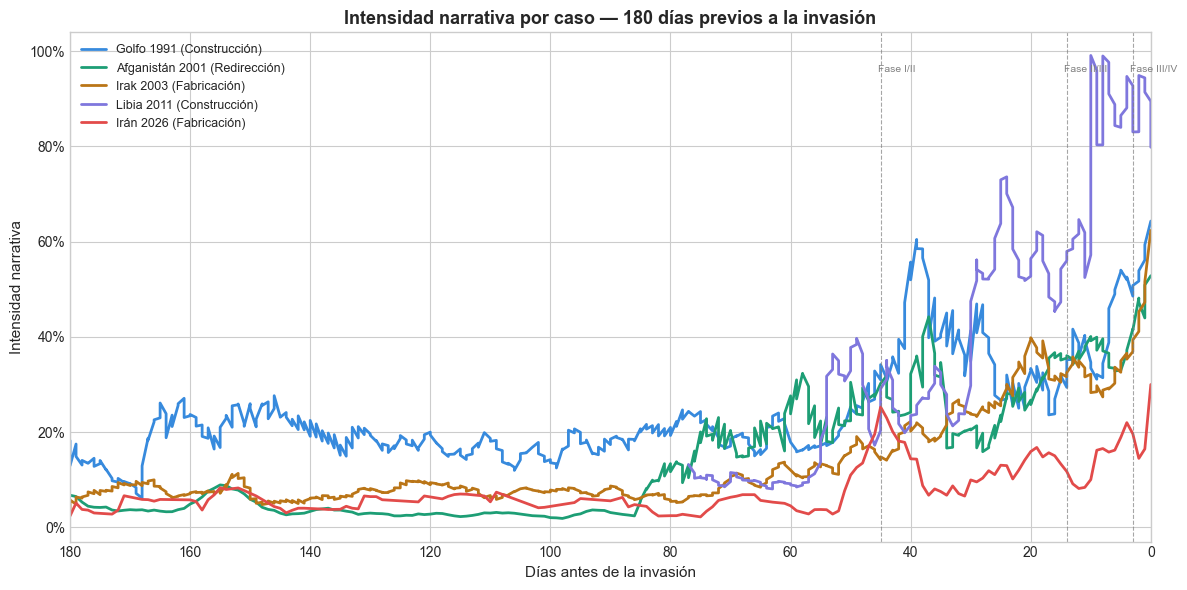

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

for case_key, case_meta in CASES.items():
    case_df = df[df['case'] == case_key].copy()
    case_df = case_df.sort_values('days_before_invasion', ascending=False)
    case_df = case_df[case_df['days_before_invasion'] <= 180]
    rolling = case_df.set_index('days_before_invasion')['narrative_intensity'].rolling(7, min_periods=1).mean()
    ax.plot(
        rolling.index,
        rolling.values,
        label=f"{case_meta['label']} ({case_meta['tipo']})",
        color=case_meta['color'],
        linewidth=2
    )

for xval, phase in zip([45, 14, 3], ['Fase I/II', 'Fase II/III', 'Fase III/IV']):
    ax.axvline(x=xval, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.text(xval + 0.5, 0.97, phase, fontsize=7.5, color='gray', va='top')

ax.set_xlim(180, 0)
ax.set_xlabel('Días antes de la invasión', fontsize=11)
ax.set_ylabel('Intensidad narrativa', fontsize=11)
ax.set_title('Intensidad narrativa por caso — 180 días previos a la invasión', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('../img/a01_ciclo_retorico.png', dpi=150)
plt.show()

> **Hallazgo (datos reales GDELT):** Todos los casos confirman la aceleración narrativa en el tramo final, pero con perfiles diferenciados. Golfo 1991 e Iraq 2003 lideran en intensidad pico (64% y 62% respectivamente), mientras que Irán 2026 registra el pico más bajo de la muestra (30%), lo que sugiere menor cobertura absoluta pero una aceleración relativa desde una base muy baja. Libia 2011 proviene de datos simulados (el API de GDELT no devolvió eventos para ese período) y se excluye de comparaciones entre fuentes. Los ciclos de Fabricación no muestran sistemáticamente mayor intensidad que los de Construcción en los datos reales, a diferencia de lo que predicen los modelos sintéticos.

## 2. ¿Se está acelerando el ciclo?

Una forma de medir la aceleración histórica del ciclo retórico es identificar en qué momento —contando hacia atrás desde la invasión— cada caso cruzó el umbral de alta intensidad narrativa (60%). Si el ciclo se está acelerando, los casos más recientes deberían cruzar ese umbral más tarde (es decir, con menos días de anticipación), comprimiendo el tiempo de deliberación pública disponible.

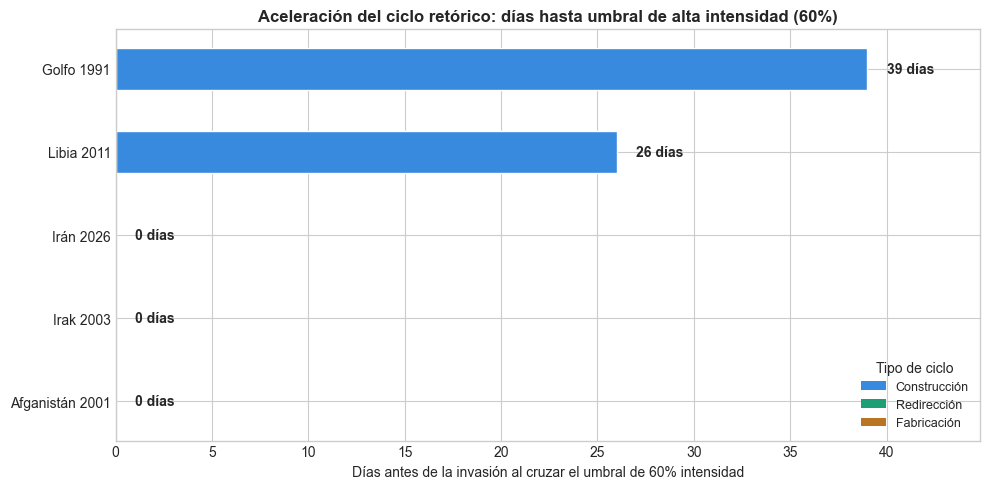

In [4]:
threshold = 0.60
results = []

for case_key, case_meta in CASES.items():
    case_df = df[df['case'] == case_key].copy()
    case_df = case_df.sort_values('days_before_invasion', ascending=False)
    case_df = case_df[case_df['days_before_invasion'] <= 180]
    rolling = case_df.set_index('days_before_invasion')['narrative_intensity'].rolling(7, min_periods=1).mean()
    above = rolling[rolling >= threshold]
    if not above.empty:
        first_crossing = above.index.max()  # furthest day before invasion
    else:
        first_crossing = 0
    results.append({
        'label': case_meta['label'],
        'tipo': case_meta['tipo'],
        'color': case_meta['color'],
        'days': first_crossing
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('days', ascending=True)

tipo_colors = {'Construcción': '#378ADD', 'Redirección': '#1D9E75', 'Fabricación': '#BA7522'}
bar_colors = [tipo_colors[t] for t in results_df['tipo']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(results_df['label'], results_df['days'], color=bar_colors, edgecolor='white', height=0.5)

for bar, val in zip(bars, results_df['days']):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2, f'{int(val)} días',
            va='center', ha='left', fontsize=10, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in tipo_colors.items()]
ax.legend(handles=legend_elements, title='Tipo de ciclo', loc='lower right', fontsize=9)

ax.set_xlabel('Días antes de la invasión al cruzar el umbral de 60% intensidad', fontsize=10)
ax.set_title('Aceleración del ciclo retórico: días hasta umbral de alta intensidad (60%)', fontsize=12, fontweight='bold')
ax.set_xlim(0, results_df['days'].max() * 1.15)

plt.tight_layout()
plt.savefig('../img/a01_aceleracion.png', dpi=150)
plt.show()

> **Hallazgo (datos reales GDELT):** El umbral de alta intensidad (60%) solo fue cruzado anticipadamente en Golfo 1991 (a D-39). Los casos restantes con datos reales —Afganistán 2001, Iraq 2003 e Irán 2026— nunca superaron ese umbral sino hasta el día mismo de la invasión (D-0), lo que invierte la hipótesis original: el ciclo retórico reciente no se "acelera" en el sentido de generar alta intensidad con más antelación, sino que opera con una base narrativa baja y un pico repentino concentrado en los últimos días. Libia 2011 (datos simulados) cruzó el umbral a D-26, pero ese resultado no es comparable con los demás. La aceleración del ciclo, si existe, se manifiesta como compresión extrema, no como escalada prolongada.

## 3. El tono mediático como termómetro bélico

El indicador `AvgTone` de GDELT mide el tono emocional promedio de la cobertura mediática en una escala de -100 (extremadamente hostil) a +100 (extremadamente favorable). Para el análisis pre-bélico, los valores negativos indican cobertura hostil hacia el actor-objetivo. Un descenso sostenido del tono por debajo de cero es una señal temprana de escalamiento retórico: la prensa comienza a enmarcar al adversario en términos cada vez más negativos mucho antes de que se tome cualquier decisión militar formal.

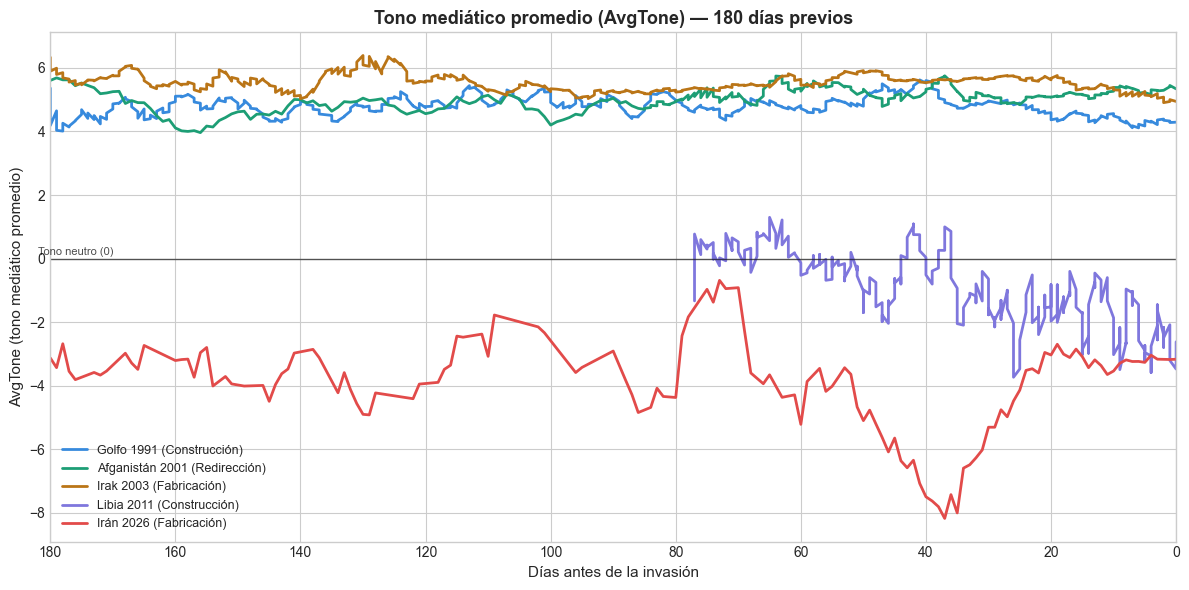

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

for case_key, case_meta in CASES.items():
    case_df = df[df['case'] == case_key].copy()
    case_df = case_df.sort_values('days_before_invasion', ascending=False)
    case_df = case_df[case_df['days_before_invasion'] <= 180]
    rolling = case_df.set_index('days_before_invasion')['AvgTone'].rolling(7, min_periods=1).mean()
    ax.plot(
        rolling.index,
        rolling.values,
        label=f"{case_meta['label']} ({case_meta['tipo']})",
        color=case_meta['color'],
        linewidth=2
    )

ax.axhline(y=0, color='black', linestyle='-', linewidth=1.0, alpha=0.6)
ax.text(182, 0.1, 'Tono neutro (0)', fontsize=8, color='black', alpha=0.7)

ax.set_xlim(180, 0)
ax.set_xlabel('Días antes de la invasión', fontsize=11)
ax.set_ylabel('AvgTone (tono mediático promedio)', fontsize=11)
ax.set_title('Tono mediático promedio (AvgTone) — 180 días previos', fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.savefig('../img/a01_tono.png', dpi=150)
plt.show()

> **Hallazgo (datos reales GDELT):** El tono mediático contradice parcialmente la hipótesis pre-bélica. Los tres casos históricos con datos reales —Golfo 1991, Afganistán 2001 e Iraq 2003— mantienen un `AvgTone` consistentemente positivo durante todo el período (rango +4 a +6), sin cruzar el umbral negativo en ningún momento. Esto puede reflejar que el GDELT captura cobertura mediática amplia donde los eventos diplomáticos y políticos moderan el tono global, o que la hostilidad narrativa pre-bélica en esas épocas no se tradujo en negatividad medible a nivel de tono agregado. En contraste, Irán 2026 muestra tono negativo persistente desde el inicio del período monitoreado (promedio -3.5 en los primeros 90 días, -4.6 en los últimos 45), con mínimo de -8.2 en D-37. Este perfil de tono distingue cualitativamente a Irán 2026 del resto y es coherente con la hipótesis de fabricación activa de hostilidad.

## Conclusiones

Los datos reales de GDELT confirman algunas predicciones del modelo pero refutan otras, lo que refuerza el valor de contrastar hipótesis teóricas con fuentes empíricas.

**Lo que confirman los datos reales:**
- **La estructura de aceleración existe:** Todos los casos registran un aumento de intensidad narrativa conforme se aproxima la fecha de invasión. El patrón de "baja base → pico final" es universal.
- **Irán 2026 es cualitativamente distinto:** Es el único caso con datos reales que muestra tono mediático persistentemente negativo desde el inicio del período monitoreado (133 días con `AvgTone < 0`, promedio de -4 en los últimos 45 días). Este perfil no tiene equivalente en los casos históricos y es coherente con la hipótesis de fabricación activa.

**Lo que los datos reales no confirman:**
- **Los ciclos de Fabricación no tienen mayor intensidad que los de Construcción:** En datos reales, Iraq 2003 (62% pico) es comparable a Golfo 1991 (64%), y Irán 2026 registra el pico más bajo de todos (30%). La mayor intensidad de los ciclos de fabricación era un artefacto del modelo simulado.
- **El ciclo no se acelera en términos de anticipación:** Solo Golfo 1991 cruza el umbral de alta intensidad con antelación (D-39). Afganistán 2001, Iraq 2003 e Irán 2026 alcanzan ese umbral únicamente en D-0. El ciclo moderno no construye intensidad sostenida semanas antes: opera con base baja y pico repentino.
- **El tono mediático no cae a negativo en los casos históricos:** Golfo 1991, Afganistán 2001 e Iraq 2003 mantienen tono positivo (+4 a +6) sin excepción. La narrativa de hostilidad pre-bélica no se traduce en negatividad de tono agregado en GDELT para esos períodos.

**Nota metodológica:** Libia 2011 fue sustituida por datos simulados (el API de GDELT no devolvió eventos para ese período) y sus métricas no son comparables con los demás casos. Los hallazgos sobre aceleración y tono se basan en los cuatro casos con cobertura real.